<a href="https://colab.research.google.com/github/hibu-11/nashville-lst/blob/main/nashville_parking_optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nashville Parking Detection — Optimized Multi-Region Pipeline
# 纳什维尔停车场检测 — 优化的多区域流程

Improvements over the previous version  相比旧版的改进:
- **Multi-region**: Downtown + West End commercial district  多研究区：市中心 + West End 商业板块
- **Overlapping sliding-window inference**: no more lots cut at tile edges  重叠滑窗推理：不再在切块边缘漏检
- **Test-time augmentation (TTA)**: flip/rotate averaging for stabler masks  测试时增强：翻转旋转平均，掩码更稳
- **Morphological post-processing**: fill holes, remove speckle  形态学后处理：填洞去噪
- **Threshold sweep**: pick the best confidence cutoff  阈值扫描：选最优置信度
- **Geometry cleanup**: cleaner polygon shapes  几何优化：更规整的多边形

**Runtime → T4 GPU.**

## 1  Install & clone  安装与克隆

In [1]:
import os, subprocess

subprocess.run(['pip', 'install', '-q',
    'transformers==4.40.0', 'pytorch-lightning==2.2.4', 'evaluate',
    'geopandas', 'shapely', 'rasterio', 'torchmetrics', 'imageio',
    'folium', 'mapbox_earcut', 'tqdm', 'osmnx', 'scikit-image'], check=True)

if not os.path.exists('parking-lot-mapping-tool'):
    subprocess.run(['git', 'clone', '--quiet',
        'https://github.com/UTEL-UIUC/parking-lot-mapping-tool.git'], check=True)
os.chdir('parking-lot-mapping-tool')

for fn in ('functions.py', 'inference.py', '_classes.csv'):
    assert os.path.exists(fn), f'{fn} missing — clone failed'
print('✓ Repo ready, cwd:', os.getcwd())

✓ Repo ready, cwd: /content/parking-lot-mapping-tool


## 2  Define study regions  定义研究区域

Two regions: Downtown CBD and the West End commercial corridor.
两个研究区：市中心 CBD 与 West End 商业走廊。

In [2]:
# Each region: center lat/lon + radius (m)  每个区域：中心经纬度 + 半径（米）
REGIONS = {
    'downtown': {
        'lat': 36.1627, 'lon': -86.7816, 'radius_m': 2500,
        'label': 'Downtown CBD 市中心',
    },
    'west_end': {
        'lat': 36.1490, 'lon': -86.8030, 'radius_m': 2500,
        'label': 'West End Commercial West End商业区',
    },
    'bellevue': {                                    # ← 新增
        'lat': 36.0555, 'lon': -86.9450, 'radius_m': 2500,
        'label': 'Bellevue Suburban Bellevue郊区',
    },
}

for k, r in REGIONS.items():
    area = 3.14159 * (r['radius_m']/1000)**2
    print(f"{k:10s}  center ({r['lat']}, {r['lon']})  r={r['radius_m']}m  ~{area:.1f} km²")

downtown    center (36.1627, -86.7816)  r=2500m  ~19.6 km²
west_end    center (36.149, -86.803)  r=2500m  ~19.6 km²
bellevue    center (36.0555, -86.945)  r=2500m  ~19.6 km²


## 3  Helper: download Esri imagery for a region  工具函数：下载某区域影像

In [3]:
import math, io, time, requests
import numpy as np
from PIL import Image
import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from tqdm.notebook import tqdm

ZOOM      = 18
TILE_SIZE = 256
ESRI_URL  = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'
HEADERS   = {'User-Agent': 'Vanderbilt-DSI-ParkingResearch/1.0 (academic)'}

def deg2tile(lat, lon, z):
    n = 2**z
    return (int((lon+180)/360*n),
            int((1-math.asinh(math.tan(math.radians(lat)))/math.pi)/2*n))
def tile2deg(xt, yt, z):
    n = 2**z
    return (math.degrees(math.atan(math.sinh(math.pi*(1-2*yt/n)))), xt/n*360-180)

def download_region(name, lat, lon, radius_m):
    """Download + stitch Esri tiles for one region → georeferenced GeoTIFF.
    下载并拼接某区域的 Esri 瓦片 → 带地理坐标的 GeoTIFF。"""
    geotiff = f'{name}_esri.tif'
    if os.path.exists(geotiff):
        print(f'  {geotiff} exists, skip.'); return geotiff
    dlat = radius_m/111320.0
    dlon = radius_m/(111320.0*math.cos(math.radians(lat)))
    x0,y0 = deg2tile(lat+dlat, lon-dlon, ZOOM)
    x1,y1 = deg2tile(lat-dlat, lon+dlon, ZOOM)
    nc,nr = x1-x0+1, y1-y0+1
    mosaic = Image.new('RGB', (nc*TILE_SIZE, nr*TILE_SIZE))
    bar = tqdm(total=nc*nr, desc=f'{name} tiles')
    for xi,x in enumerate(range(x0,x1+1)):
        for yi,y in enumerate(range(y0,y1+1)):
            for att in range(3):
                try:
                    r=requests.get(ESRI_URL.format(z=ZOOM,x=x,y=y),headers=HEADERS,timeout=15)
                    r.raise_for_status()
                    mosaic.paste(Image.open(io.BytesIO(r.content)).convert('RGB'),
                                 (xi*TILE_SIZE,yi*TILE_SIZE)); break
                except Exception as e:
                    if att==2: print(f'    tile ({x},{y}) failed: {e}')
                    time.sleep(1)
            bar.update(1)
    bar.close()
    n_e,w_e = tile2deg(x0,y0,ZOOM); s_e,e_e = tile2deg(x1+1,y1+1,ZOOM)
    arr=np.array(mosaic)
    tf=from_bounds(w_e,s_e,e_e,n_e,arr.shape[1],arr.shape[0])
    with rasterio.open(geotiff,'w',driver='GTiff',height=arr.shape[0],width=arr.shape[1],
                       count=3,dtype=arr.dtype,crs=CRS.from_epsg(4326),transform=tf) as dst:
        for b in range(3): dst.write(arr[:,:,b],b+1)
    print(f'  ✓ {geotiff}  ({arr.shape[1]}×{arr.shape[0]} px)')
    return geotiff

# Download all regions  下载所有区域
for name, r in REGIONS.items():
    print(f'Region 区域: {name}')
    download_region(name, r['lat'], r['lon'], r['radius_m'])
print('✓ All regions downloaded')

Region 区域: downtown


downtown tiles:   0%|          | 0/1681 [00:00<?, ?it/s]

  ✓ downtown_esri.tif  (10496×10496 px)
Region 区域: west_end


west_end tiles:   0%|          | 0/1764 [00:00<?, ?it/s]

  ✓ west_end_esri.tif  (10752×10752 px)
Region 区域: bellevue


bellevue tiles:   0%|          | 0/1681 [00:00<?, ?it/s]

  ✓ bellevue_esri.tif  (10496×10496 px)
✓ All regions downloaded


## 4  Helper: reproject to EPSG:3857  工具函数：重投影

In [4]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

def reproject_region(name):
    """Reproject a region's GeoTIFF to EPSG:3857.  重投影到 EPSG:3857。"""
    src_path = f'{name}_esri.tif'
    dst_path = f'{name}_esri_3857.tif'
    if os.path.exists(dst_path):
        print(f'  {dst_path} exists, skip.'); return dst_path
    dst_crs = CRS.from_epsg(3857)
    with rasterio.open(src_path) as src:
        tf,w,h = calculate_default_transform(src.crs, dst_crs, src.width, src.height, *src.bounds)
        meta = src.meta.copy(); meta.update(crs=dst_crs, transform=tf, width=w, height=h)
        with rasterio.open(dst_path,'w',**meta) as dst:
            for i in range(1,4):
                reproject(rasterio.band(src,i), rasterio.band(dst,i),
                          src_transform=src.transform, src_crs=src.crs,
                          dst_transform=tf, dst_crs=dst_crs, resampling=Resampling.bilinear)
    with rasterio.open(dst_path) as d:
        print(f'  ✓ {dst_path}  {d.width}×{d.height} px')
    return dst_path

for name in REGIONS:
    print(f'Region {name}:'); reproject_region(name)
print('✓ All reprojected')

Region downtown:
  ✓ downtown_esri_3857.tif  10496×10496 px
Region west_end:
  ✓ west_end_esri_3857.tif  10752×10752 px
Region bellevue:
  ✓ bellevue_esri_3857.tif  10496×10496 px
✓ All reprojected


## 5  Load SegFormer model (verified)  加载模型（含验证）

In [5]:
import sys, torch
from transformers import SegformerFeatureExtractor
from huggingface_hub import hf_hub_download
sys.path.insert(0, '.')
from inference import SegformerFinetuner

DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
IM_SIZE = 512
print('Device 设备:', DEVICE)

# Parse _classes.csv (strip BOM + whole-line quotes)  解析类别文件
id2label = {}
with open('_classes.csv', encoding='utf-8-sig') as f:
    for i, line in enumerate(f):
        line = line.strip().strip('"')
        if i == 0 or not line: continue
        parts = [p.strip().strip('"') for p in line.split(',')]
        if len(parts) >= 2: id2label[parts[0]] = parts[1]
assert id2label == {'0': 'background', '1': 'parking_lot'}, f'parse error: {id2label}'
print('id2label:', id2label)

feature_extractor = SegformerFeatureExtractor.from_pretrained(
    'nvidia/segformer-b5-finetuned-cityscapes-1024-1024',
    do_reduce_labels=False, size=512)

ckpt = torch.load(hf_hub_download('UTEL-UIUC/SegFormer-large-parking', 'best_model.ckpt'),
                  map_location=DEVICE)
model_sd = {(k[len('model.'):] if k.startswith('model.') else k): v
            for k, v in ckpt['state_dict'].items()}

segformer = SegformerFinetuner(id2label=id2label)
clf_before = segformer.model.decode_head.classifier.weight.detach().clone()
segformer.model.load_state_dict(model_sd, strict=False)
clf_after = segformer.model.decode_head.classifier.weight.detach()
segformer.model.to(DEVICE).eval()
assert not torch.allclose(clf_before, clf_after), 'Classifier head not loaded!'
print('✓ Model loaded & verified  模型加载并验证')

Device 设备: cuda
id2label: {'0': 'background', '1': 'parking_lot'}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/273 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/segformer/feature_extraction_segformer.py:28: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/models/segformer/image_processing_segformer.py:103: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(


best_model.ckpt:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/339M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b5-finetuned-cityscapes-1024-1024 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([19, 768, 1, 1]) in the checkpoint and torch.Size([2, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([19]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded & verified  模型加载并验证


## 6  Improved inference engine  改进的推理引擎

Key upgrades  核心升级:
- **Overlapping sliding window** (stride < tile): lots at tile borders are no
  longer split. Overlapping predictions are blended by averaging.
  **重叠滑窗**（步长<块大小）：块边缘的停车场不再被切断，重叠区取平均融合。
- **Test-time augmentation**: average over horizontal/vertical flips.
  **测试时增强**：对水平/垂直翻转结果取平均。
These reduce edge artifacts and stabilize the probability map.
两者共同减少边缘伪影、稳定概率图。

In [6]:
import numpy as np, torch, gc
from torch import nn
from PIL import Image

def _predict_tile_prob(tile_rgb, use_tta=True):
    """Return parking probability map for a 512x512 tile (with optional TTA).
    返回单个 512×512 块的停车概率图（可选 TTA）。"""
    variants = [tile_rgb]
    if use_tta:
        variants += [np.fliplr(tile_rgb), np.flipud(tile_rgb)]  # H flip, V flip
    probs = []
    for k, v in enumerate(variants):
        enc   = feature_extractor(Image.fromarray(np.ascontiguousarray(v)),
                                  return_tensors='pt')
        imgs  = enc['pixel_values'].to(DEVICE)
        dummy = torch.zeros(1, IM_SIZE, IM_SIZE, dtype=torch.long).to(DEVICE)
        with torch.no_grad():
            _, logits = segformer.model(pixel_values=imgs, labels=dummy)
        up = nn.functional.interpolate(logits, size=(IM_SIZE, IM_SIZE),
                                       mode='bilinear', align_corners=False)
        p = nn.functional.softmax(up, dim=1)[0, 1].cpu().numpy()
        # undo the flip so all variants align  反变换对齐
        if use_tta and k == 1: p = np.fliplr(p)
        if use_tta and k == 2: p = np.flipud(p)
        probs.append(p)
    return np.mean(probs, axis=0)

def infer_region_prob(repr_path, stride=384, use_tta=True):
    """Overlapping sliding-window inference → full-region probability map.
    重叠滑窗推理 → 整区概率图。stride<512 产生重叠。"""
    with rasterio.open(repr_path) as src:
        W, H = src.width, src.height
        img = np.moveaxis(src.read([1,2,3]), 0, -1).astype(np.uint8)
    prob_sum = np.zeros((H, W), np.float32)
    prob_cnt = np.zeros((H, W), np.float32)
    ys = list(range(0, max(1, H-IM_SIZE)+1, stride)) + [max(0, H-IM_SIZE)]
    xs = list(range(0, max(1, W-IM_SIZE)+1, stride)) + [max(0, W-IM_SIZE)]
    ys, xs = sorted(set(ys)), sorted(set(xs))
    total = len(ys)*len(xs)
    bar = tqdm(total=total, desc='sliding window')
    for y in ys:
        for x in xs:
            tile = img[y:y+IM_SIZE, x:x+IM_SIZE]
            h, w = tile.shape[:2]
            if h < IM_SIZE or w < IM_SIZE:
                pad = np.zeros((IM_SIZE, IM_SIZE, 3), np.uint8); pad[:h,:w]=tile; tile=pad
            p = _predict_tile_prob(tile, use_tta=use_tta)
            prob_sum[y:y+h, x:x+w] += p[:h, :w]
            prob_cnt[y:y+h, x:x+w] += 1.0
            bar.update(1)
    bar.close()
    prob = np.divide(prob_sum, prob_cnt, out=np.zeros_like(prob_sum), where=prob_cnt>0)
    gc.collect(); torch.cuda.empty_cache()
    return prob

print('✓ Inference engine ready (overlap + TTA)  推理引擎就绪')

✓ Inference engine ready (overlap + TTA)  推理引擎就绪


## 7  Threshold sweep on one region  单区阈值扫描

Compute the probability map once, then try several thresholds to see how
predicted area changes — helps pick a cutoff that captures real lots without
flooding rooftops.
先算一次概率图，再试多个阈值观察预测面积变化，选出既抓真停车场又不淹屋顶的阈值。

sliding window:   0%|          | 0/729 [00:00<?, ?it/s]

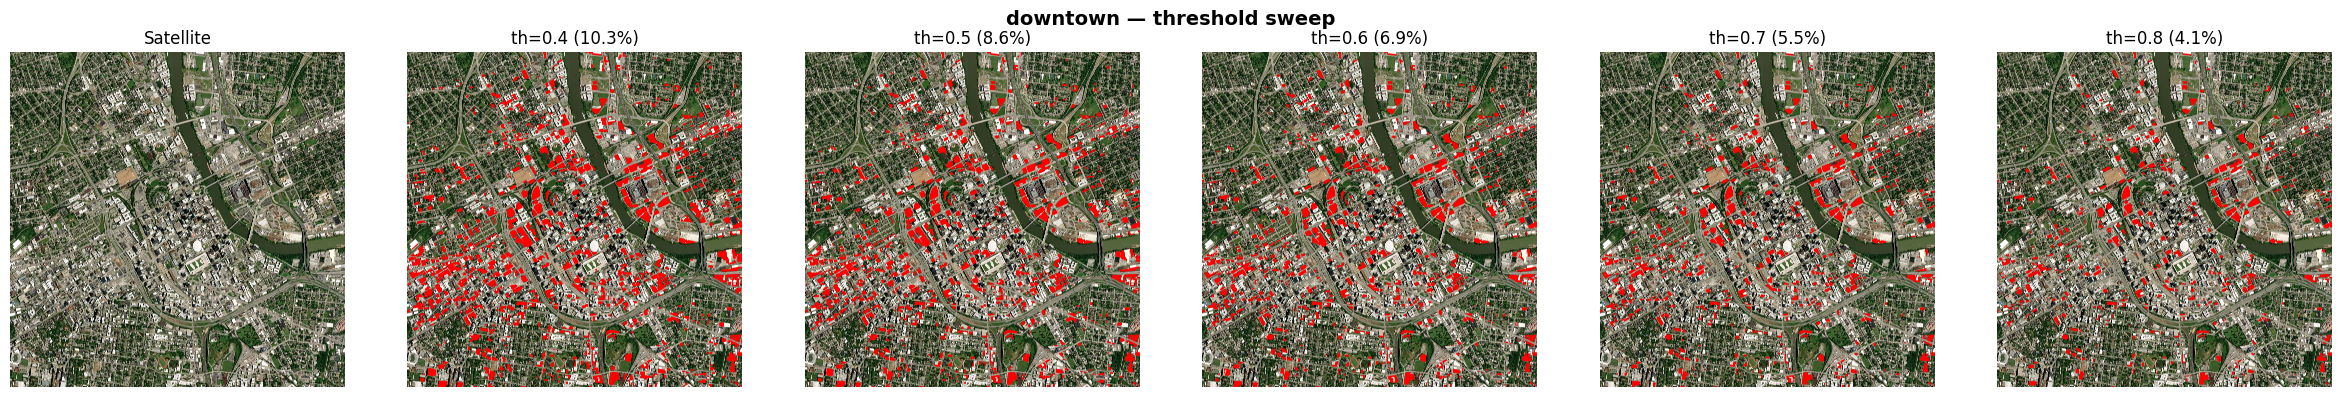

✓ Inspect the sweep, then set THRESHOLD below  查看后设定阈值


In [7]:
import matplotlib.pyplot as plt

# Use downtown to tune  用市中心调参
TUNE_REGION = 'downtown'
repr_path = f'{TUNE_REGION}_esri_3857.tif'
prob_map = infer_region_prob(repr_path, stride=384, use_tta=True)
np.save(f'{TUNE_REGION}_prob.npy', prob_map)   # cache  缓存

with rasterio.open(repr_path) as src:
    img = np.moveaxis(src.read([1,2,3]), 0, -1).astype(np.uint8)

thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]
fig, ax = plt.subplots(1, len(thresholds)+1, figsize=(4*(len(thresholds)+1), 4))
ax[0].imshow(img); ax[0].set_title('Satellite'); ax[0].axis('off')
for k, th in enumerate(thresholds):
    mask = prob_map > th
    ov = img.copy(); ov[mask] = [255,0,0]
    ax[k+1].imshow(ov); ax[k+1].set_title(f'th={th} ({mask.mean()*100:.1f}%)')
    ax[k+1].axis('off')
plt.suptitle(f'{TUNE_REGION} — threshold sweep', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{TUNE_REGION}_threshold_sweep.png', dpi=120,
                                 bbox_inches='tight'); plt.show()
print('✓ Inspect the sweep, then set THRESHOLD below  查看后设定阈值')

## 8  Post-processing: mask → clean polygons  后处理：掩码→规整多边形

1. Threshold the probability map  阈值化概率图
2. Morphological close/open: fill small holes, remove speckle  形态学闭/开运算：填洞去噪
3. Vectorize + simplify + area filter  矢量化+简化+面积过滤
4. Geometry cleanup (hybrid rectangle snapping)  几何优化（混合矩形规整）

In [10]:
from skimage.morphology import binary_closing, binary_opening, disk, remove_small_objects
from rasterio.features import shapes as rio_shapes
import geopandas as gpd
from shapely.geometry import shape as shapely_shape

# ── Set your chosen threshold from Cell 7  设定你选的阈值 ─────────────────────
THRESHOLD = 0.6
MIN_AREA_M2 = 100         # drop lots smaller than this  过滤过小多边形
SIMPLIFY_TOL = 1.5        # meters, edge simplification  边缘简化容差（米）
RECT_SNAP_THRESH = 0.85   # snap to rectangle if ≥ this rectangularity  接近矩形则规整

def mask_to_polygons(prob_map, repr_path, threshold=0.6):
    """Full post-processing chain → cleaned GeoDataFrame (EPSG:3857).
    完整后处理链 → 规整后的多边形（EPSG:3857）。"""
    mask = (prob_map > threshold)
    # Morphological cleanup  形态学清理
    mask = binary_closing(mask, disk(3))   # fill small gaps/holes 填小洞
    mask = binary_opening(mask, disk(2))   # remove speckle 去碎点
    mask = remove_small_objects(mask, min_size=200)  # drop tiny blobs 去小块
    mask = mask.astype(np.uint8)

    with rasterio.open(repr_path) as src:
        transform, crs = src.transform, src.crs
    # Vectorize  矢量化
    polys = [shapely_shape(geom) for geom, val in
             rio_shapes(mask, mask=mask.astype(bool), transform=transform) if val == 1]
    gdf = gpd.GeoDataFrame(geometry=polys, crs=crs)
    gdf = gdf[gdf.geometry.is_valid & ~gdf.geometry.is_empty]

    # Area filter (in meters)  面积过滤
    gdf_m = gdf.to_crs('EPSG:32616')
    gdf_m = gdf_m[gdf_m.geometry.area >= MIN_AREA_M2].reset_index(drop=True)

    # Simplify + hybrid rectangle snapping  简化 + 混合矩形规整
    cleaned = []
    for g in gdf_m.geometry:
        s = g.simplify(SIMPLIFY_TOL, preserve_topology=True)
        mr = s.minimum_rotated_rectangle
        if mr.area > 0 and (s.area/mr.area) >= RECT_SNAP_THRESH:
            cleaned.append(mr)     # near-rectangular → snap 接近矩形则规整
        else:
            cleaned.append(s)      # irregular → keep 不规则则保留
    out = gpd.GeoDataFrame(geometry=cleaned, crs='EPSG:32616')
    out = out[out.geometry.is_valid & ~out.geometry.is_empty].reset_index(drop=True)
    return out.to_crs('EPSG:3857')

# Run for the tuned region  对调参区域运行
gdf_dt = mask_to_polygons(prob_map, repr_path, threshold=THRESHOLD)
gdf_dt.to_file(f'{TUNE_REGION}_parking.geojson', driver='GeoJSON')
area_km2 = gdf_dt.to_crs('EPSG:32616').geometry.area.sum()/1e6
print(f'✓ {TUNE_REGION}: {len(gdf_dt)} polygons, {area_km2:.3f} km²  (th={THRESHOLD})')

✓ downtown: 654 polygons, 1.782 km²  (th=0.6)


## 9  Run all regions  对所有区域运行完整流程

In [11]:
region_results = {}
for name in REGIONS:
    print(f'\n=== Region 区域: {name} ===')
    rp = f'{name}_esri_3857.tif'
    cache = f'{name}_prob.npy'
    if os.path.exists(cache):
        prob = np.load(cache); print('  loaded cached prob map  载入缓存概率图')
    else:
        prob = infer_region_prob(rp, stride=384, use_tta=True)
        np.save(cache, prob)
    gdf_r = mask_to_polygons(prob, rp, threshold=THRESHOLD)
    gdf_r.to_file(f'{name}_parking.geojson', driver='GeoJSON')
    a = gdf_r.to_crs('EPSG:32616').geometry.area.sum()/1e6
    region_results[name] = gdf_r
    print(f'  ✓ {len(gdf_r)} polygons, {a:.3f} km²')
print('\n✓ All regions done')


=== Region 区域: downtown ===
  loaded cached prob map  载入缓存概率图
  ✓ 654 polygons, 1.782 km²

=== Region 区域: west_end ===


sliding window:   0%|          | 0/784 [00:00<?, ?it/s]

  ✓ 653 polygons, 1.804 km²

=== Region 区域: bellevue ===


sliding window:   0%|          | 0/729 [00:00<?, ?it/s]

  ✓ 199 polygons, 0.619 km²

✓ All regions done


## 10  OSM reference + intersection check per region  各区 OSM 对比与交叉核对

In [12]:
import osmnx as ox
from shapely.ops import unary_union

def osm_parking(name, lat, lon, radius_m):
    f = f'{name}_osm_parking.geojson'
    if not os.path.exists(f):
        o = ox.features_from_point((lat, lon), tags={'amenity':'parking'}, dist=radius_m)
        o = o[o.geometry.type.isin(['Polygon','MultiPolygon'])][['geometry']].reset_index(drop=True)
        o.to_file(f, driver='GeoJSON')
    return gpd.read_file(f).set_crs('EPSG:4326').to_crs('EPSG:32616')

print('═'*66)
print(f'  {"Region":<12}{"Pred km²":<11}{"OSM km²":<11}{"IoU":<8}{"Overlap/OSM":<12}')
print('═'*66)
osm_results = {}
for name, r in REGIONS.items():
    gdf_r = region_results[name]
    osm = osm_parking(name, r['lat'], r['lon'], r['radius_m'])
    osm_results[name] = osm
    pred_u = unary_union(gdf_r.to_crs('EPSG:32616').geometry.values)
    osm_u  = unary_union(osm.geometry.values)
    inter = pred_u.intersection(osm_u).area
    union = pred_u.union(osm_u).area
    iou   = inter/union if union else 0
    rec   = inter/osm_u.area if osm_u.area else 0
    print(f'  {name:<12}{pred_u.area/1e6:<11.3f}{osm_u.area/1e6:<11.3f}{iou:<8.3f}{rec:<12.3f}')
print('═'*66)
print('  OSM = crowd-sourced reference (incomplete), not ground truth.')

══════════════════════════════════════════════════════════════════
  Region      Pred km²   OSM km²    IoU     Overlap/OSM 
══════════════════════════════════════════════════════════════════
  downtown    1.782      1.451      0.356   0.585       
  west_end    1.804      1.552      0.392   0.609       
  bellevue    0.619      0.194      0.253   0.845       
══════════════════════════════════════════════════════════════════
  OSM = crowd-sourced reference (incomplete), not ground truth.


## 11  Interactive map — all regions  交互地图（所有区域）

In [13]:
import folium
from IPython.display import IFrame

# Center between the two regions  以两区中点为中心
clat = np.mean([r['lat'] for r in REGIONS.values()])
clon = np.mean([r['lon'] for r in REGIONS.values()])
m = folium.Map(location=[clat, clon], zoom_start=13, tiles=None)
folium.TileLayer(
    'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri', name='Satellite').add_to(m)
folium.TileLayer('CartoDB positron', name='Map').add_to(m)

colors = {
    'downtown': ('#FF4444','#CC0000'),
    'west_end': ('#4488FF','#0044CC'),
    'bellevue': ('#FF9933','#CC6600'),    # ← 新增，橙色
}
for name, r in REGIONS.items():
    fc, ec = colors.get(name, ('#FF9933','#CC6600'))
    gdf_w = region_results[name].to_crs('EPSG:4326')
    folium.GeoJson(gdf_w.__geo_interface__, name=f'{name} prediction',
        style_function=lambda _f, fc=fc, ec=ec: {'fillColor':fc,'color':ec,
                       'weight':0.8,'fillOpacity':0.5}).add_to(m)
    osm_w = osm_results[name].to_crs('EPSG:4326')
    folium.GeoJson(osm_w.__geo_interface__, name=f'{name} OSM',
        style_function=lambda _f: {'fillColor':'#33FF88','color':'#00AA44',
                       'weight':1.2,'fillOpacity':0.0}).add_to(m)
    folium.Circle([r['lat'], r['lon']], radius=r['radius_m'], color='black',
                  fill=False, weight=1.5, dash_array='6',
                  popup=r['label']).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
legend = '''<div style="position:fixed;top:10px;left:50px;z-index:1000;background:white;
  padding:10px;border:2px solid #888;border-radius:5px;font:13px Arial;line-height:1.6;">
  <b>Nashville Parking — Multi-Region</b><br>
  <span style="color:#FF4444;">■</span> Downtown prediction<br>
  <span style="color:#4488FF;">■</span> West End prediction<br>
  <span style="color:#FF9933;">■</span> Bellevue prediction<br>
  <span style="color:#00AA44;">▭</span> OSM parking (reference)</div>'''
m.get_root().html.add_child(folium.Element(legend))
m.save('nashville_multiregion_map.html')
print('✓ Saved nashville_multiregion_map.html')
IFrame('nashville_multiregion_map.html', width=980, height=680)

✓ Saved nashville_multiregion_map.html


## 12  Export  导出（含 LST 融合掩码）

In [14]:
from rasterio.features import rasterize

outs = []
for name in REGIONS:
    gdf_r = region_results[name]
    # rasterize prediction for LST fusion  栅格化用于 LST 融合
    rp = f'{name}_esri_3857.tif'
    with rasterio.open(rp) as src:
        meta = src.meta.copy(); meta.update(count=1, dtype='uint8')
        burned = rasterize(((g,1) for g in gdf_r.geometry),
                           out_shape=(src.height, src.width),
                           transform=src.transform, fill=0, dtype='uint8')
    mt = f'{name}_parking_mask.tif'
    with rasterio.open(mt, 'w', **meta) as dst: dst.write(burned, 1)
    outs += [f'{name}_parking.geojson', mt]

outs += ['nashville_multiregion_map.html']
print('Output files  输出文件:')
for f in outs:
    if os.path.exists(f):
        print(f'  {f:<34} {os.path.getsize(f)/1024:8.1f} KB')
print('\nDownload:')
print('  from google.colab import files')
for f in outs:
    print(f'  files.download("{f}")')

Output files  输出文件:
  downtown_parking.geojson              578.1 KB
  downtown_parking_mask.tif          107645.9 KB
  west_end_parking.geojson              596.2 KB
  west_end_parking_mask.tif          112959.4 KB
  bellevue_parking.geojson              222.4 KB
  bellevue_parking_mask.tif          107645.9 KB
  nashville_multiregion_map.html       1832.8 KB

Download:
  from google.colab import files
  files.download("downtown_parking.geojson")
  files.download("downtown_parking_mask.tif")
  files.download("west_end_parking.geojson")
  files.download("west_end_parking_mask.tif")
  files.download("bellevue_parking.geojson")
  files.download("bellevue_parking_mask.tif")
  files.download("nashville_multiregion_map.html")
